This file is for comparing FNOs with and without additions taken from the CNO architecture. The goal is to see what we can learn from the CNO to apply to other architectures.

Evaluating FNO: 100%|██████████| 9/9 [00:36<00:00,  4.01s/it]


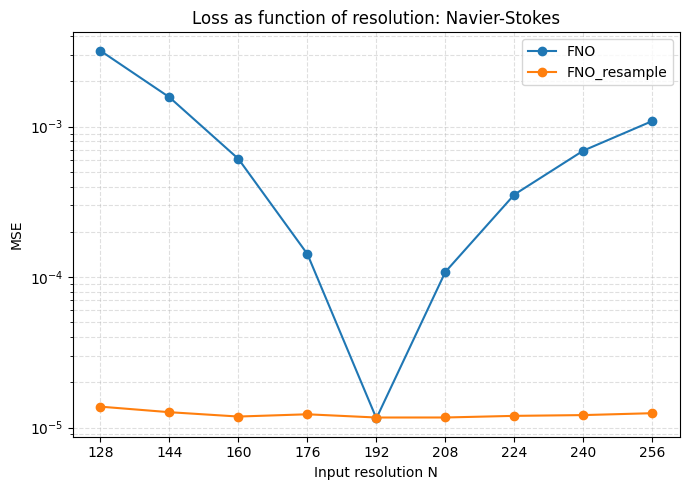

DI value of FNO: 3.4817
DI value of FNO_resample: 0.0490


In [1]:
import h5py
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("/home/mnhagen/scripts/FNO")
from tqdm import tqdm
from FNO.FNO2D_def import FNO2D
from FNO.FNO2D_def_UND import FNO2D as FNO2D_UND
from FNO.FNO2D_def_resample import FNO2D as FNO2D_resample
from FNO.FNO2D_def_resample_UND import FNO2D as FNO2D_resample_UND

# ============================================================
# CONFIG
# ============================================================
h5_path = "/scratch/mnhagen/datasets/navier_stokes_multires/navier_stokes2D_S1000_N256_multi.h5"   
dataset_key = "omega"                        
device = "cuda:0" if torch.cuda.is_available() else "cpu"

resolutions = np.arange(128, 257, 16)
batch_size = 10
res = 192

# ============================================================
# INTERPOLATION
# ============================================================
def bicubic_resample_2d(x, out_h, out_w):
    # x: [B, C, H, W]
    return F.interpolate(
        x,
        size=(out_h, out_w),
        mode="bicubic",
        align_corners=False,
        antialias=True
    )

# ============================================================
# LOAD TEST DATA (last 200 samples)
# ============================================================
with h5py.File(h5_path, "r") as f:
    data = torch.tensor(f[dataset_key][:], dtype=torch.float32)
    # shape: [1000, 2, 256, 256]

test_data = data[800:]            # last 200 samples
u0 = test_data[:, 0:1]            # [B,1,256,256]
uT = test_data[:, 1:2]

# ============================================================
# EVALUATION FUNCTION
# ============================================================
def evaluate_FNO(model):
    model.eval()
    model.to(device)

    losses = []

    with torch.no_grad():
        for N in tqdm(resolutions, desc=f"Evaluating FNO"):

            mse_sum = 0.0
            count = 0

            for i in range(0, u0.shape[0], batch_size):
                x = u0[i:i+batch_size].to(device)
                y = uT[i:i+batch_size].to(device)

                #x = x.permute(0,2,3,1)
                xN = bicubic_resample_2d(x, N, N)
                pred = model(xN)
                pred = pred.permute(0,3,1,2)

                yN = bicubic_resample_2d(y, N, N)

                if pred.shape[-1] != N:
                    pred = bicubic_resample_2d(pred, N, N)

                mse = F.mse_loss(pred, yN, reduction="sum")
                mse_sum += mse.item()
                count += pred.numel()

            losses.append(mse_sum / count)

    return np.array(losses)

#Load models

width = 128
FNO_path = f"/scratch/mnhagen/models/navier_stokes/FNO2D_navier_stokes_N{res}_k16(full).pt"
FNO_UND_path = f"/scratch/mnhagen/models/navier_stokes/FNO2D_navier_stokes_N{res}_k16(full)_UND.pt"
FNO_resample_path = f"/scratch/mnhagen/models/navier_stokes/FNO2D_navier_stokes_N{res}_k16(full)_resample.pt"
FNO_resample_UND_path = f"/scratch/mnhagen/models/navier_stokes/FNO2D_navier_stokes_N{res}_k16(full)_resample_UND.pt"

FNO = FNO2D(16, 16, width)
FNO.q = torch.nn.Conv2d(width, 1, 1)
FNO.load_state_dict(torch.load(FNO_path, map_location=device))
FNO = FNO.to(device).eval()

FNO_UND = FNO2D_UND(16, 16, width)
FNO_UND.q = torch.nn.Conv2d(width, 1, 1)
FNO_UND.load_state_dict(torch.load(FNO_UND_path, map_location=device))
FNO_UND = FNO_UND.to(device).eval()

FNO_resample = FNO2D_resample(16, 16, width, res)
FNO_resample.q = torch.nn.Conv2d(width, 1, 1)
FNO_resample.load_state_dict(torch.load(FNO_resample_path, map_location=device))
FNO_resample = FNO_resample.to(device).eval()

FNO_resample_UND = FNO2D_resample_UND(16, 16, width, res)
FNO_resample_UND.q = torch.nn.Conv2d(width, 1, 1)
FNO_resample_UND.load_state_dict(torch.load(FNO_resample_UND_path, map_location=device))
FNO_resample_UND = FNO_resample_UND.to(device).eval()

models = {
    "FNO": (FNO),
    "FNO_UND": (FNO_UND),
    "FNO_resample": (FNO_resample),
    "FNO_resample_UND": (FNO_resample_UND)
}

models = {
    "FNO": (FNO),
    "FNO_resample": (FNO_resample),
}

results = {}

for name, (model) in models.items():
    results[name] = evaluate_FNO(model)

#Plot model comparison

plt.figure(figsize=(7,5))

for name, losses in results.items():
    plt.plot(resolutions, losses, marker="o", label=name)

plt.yscale("log")

plt.xlabel("Input resolution N")
plt.xticks(resolutions, resolutions)
plt.ylabel("MSE")
plt.title("Loss as function of resolution: Navier-Stokes")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

train_idx = 4

def DI_log_mean_abs(loss, train_idx, eps = 1e-12):
    loss = np.asarray(loss, dtype = float)
    ref = loss[train_idx]
    return np.mean(np.abs(np.log(loss + eps) - np.log(ref + eps)))

for name, losses in results.items():
    print(f"DI value of {name}: {DI_log_mean_abs(losses, train_idx):.4f}")